<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Packages" data-toc-modified-id="Packages-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Packages</a></span></li><li><span><a href="#Load-palatals-csv" data-toc-modified-id="Load-palatals-csv-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span>Load palatals csv</a></span></li></ul></li><li><span><a href="#Frequencies" data-toc-modified-id="Frequencies-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Frequencies</a></span></li><li><span><a href="#Plot" data-toc-modified-id="Plot-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Plot</a></span></li></ul></div>

## Packages

In [1]:
import os
import re

import codecs
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## Load palatals csv

In [2]:
entries_df = pd.read_csv('wikcionario_gl_pt_es_la-lh-nh_alt - latin.csv') 
entries_df

,gl,pt,es,la,gl_la,pt_la,es_la,notas,gl_la_2,pt_la_2,es_la_2,gl_simple,pt_simple,es_simple
0,orella,orelha,oreja,auricula,cul,cul,NaN,NaN,cl,cl,NaN,velar+l,velar+l,NaN
1,ollo,olho,ojo,oculus,cul,cul,NaN,NaN,cl,cl,NaN,velar+l,velar+l,NaN
2,ventrullo,barriga,barriga,ventriculum,cul,NaN,NaN,NaN,cl,NaN,NaN,velar+l,NaN,NaN
3,sobrecella,sobrancelha,ceja,supercilium,li,li,NaN,NaN,li,li,NaN,l+i,l+i,NaN
4,unlla,unha,uña,ungulam,ngul,ng,ng,NaN,ng,ng,ng,nasal+velar,nasal+velar,nasal+velar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,pulso,pulso,muñeca,pulsus\monneka,NaN,NaN,nn,es_substrato pré-romano,NaN,NaN,NaN,NaN,NaN,long_n
122,ano,ano,año,annus,NaN,NaN,nn,NaN,NaN,NaN,NaN,NaN,NaN,long_n
123,tinxir,tingir,teñir,tingere,NaN,NaN,ng,NaN,NaN,NaN,ng,NaN,NaN,nasal+velar
124,constrinxir,constringir,constreñir,constringere,NaN,NaN,ng,NaN,NaN,NaN,ng,NaN,NaN,nasal+velar


# Frequencies

In [3]:
gl_la_cat = pd.DataFrame()
gl_la_cat['counts'] = entries_df['gl_simple'].value_counts()
gl_la_cat = gl_la_cat.reset_index()
gl_la_cat.columns = ['category', 'gl_counts']
gl_la_cat['gl_counts'] = gl_la_cat.gl_counts/gl_la_cat["gl_counts"].sum()
gl_la_cat

,category,gl_counts
0,nasal+i,0.449275
1,velar+l,0.260870
2,l+i,0.231884
3,nasal+velar,0.043478
4,long_n,0.014493


In [4]:
pt_la_cat = pd.DataFrame()
pt_la_cat['counts'] = entries_df['pt_simple'].value_counts()
pt_la_cat = pt_la_cat.reset_index()
pt_la_cat.columns = ['category', 'pt_counts']
pt_la_cat['pt_counts'] = pt_la_cat.pt_counts/pt_la_cat["pt_counts"].sum()
pt_la_cat

,category,pt_counts
0,nasal+i,0.441176
1,velar+l,0.250000
2,l+i,0.235294
3,nasal+velar,0.044118
4,long_l,0.014706
5,long_n,0.014706


In [5]:
es_la_cat = pd.DataFrame()
es_la_cat['counts'] = entries_df['es_simple'].value_counts()
es_la_cat = es_la_cat.reset_index()
es_la_cat.columns = ['category', 'es_counts']
es_la_cat['es_counts'] = es_la_cat.es_counts/es_la_cat["es_counts"].sum()
es_la_cat

,category,es_counts
0,long_l,0.538462
1,nasal+velar,0.115385
2,l+i,0.115385
3,initialstop+l,0.096154
4,velar+l,0.076923
5,long_n,0.057692


In [6]:
la_transform_df = pd.merge(gl_la_cat, pt_la_cat, how='outer', on='category')
la_transform_df = pd.merge(la_transform_df, es_la_cat, how='outer', on='category')

la_transform_df

,category,gl_counts,pt_counts,es_counts
0,nasal+i,0.449275,0.441176,NaN
1,velar+l,0.260870,0.250000,0.076923
2,l+i,0.231884,0.235294,0.115385
3,nasal+velar,0.043478,0.044118,0.115385
4,long_n,0.014493,0.014706,0.057692
5,long_l,NaN,0.014706,0.538462
6,initialstop+l,NaN,NaN,0.096154


In [7]:
la_transform_df = la_transform_df.set_index(["category"])
la_transform_df

,gl_counts,pt_counts,es_counts
category,,,
nasal+i,0.449275,0.441176,NaN
velar+l,0.260870,0.250000,0.076923
l+i,0.231884,0.235294,0.115385
nasal+velar,0.043478,0.044118,0.115385
long_n,0.014493,0.014706,0.057692
long_l,NaN,0.014706,0.538462
initialstop+l,NaN,NaN,0.096154


In [8]:
la_transform_nasal_df = la_transform_df.loc[["nasal+i","nasal+velar","long_n"]]
la_transform_nasal_df

,gl_counts,pt_counts,es_counts
category,,,
nasal+i,0.449275,0.441176,NaN
nasal+velar,0.043478,0.044118,0.115385
long_n,0.014493,0.014706,0.057692


In [9]:
la_transform_velar_df = la_transform_df
la_transform_velar_df.drop(index=la_transform_velar_df.index[[0,3,4]], axis=0, inplace=True)

la_transform_velar_df

,gl_counts,pt_counts,es_counts
category,,,
velar+l,0.260870,0.250000,0.076923
l+i,0.231884,0.235294,0.115385
long_l,NaN,0.014706,0.538462
initialstop+l,NaN,NaN,0.096154


# Plot

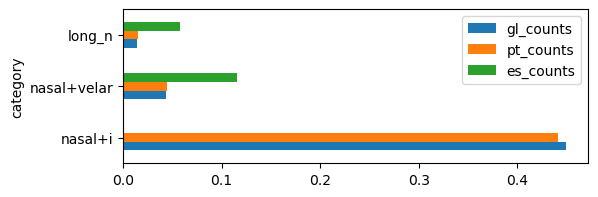

In [10]:
idx = la_transform_nasal_df.index.tolist()

la_transform_nasal_df.plot.barh(figsize=(6, 2))

plt.show()

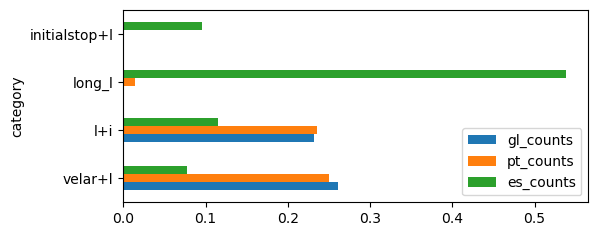

In [11]:
idx = la_transform_velar_df.index.tolist()

la_transform_velar_df.plot.barh(figsize=(6, 2.5))

plt.show()